In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [14]:
df = pd.read_csv('../../data/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


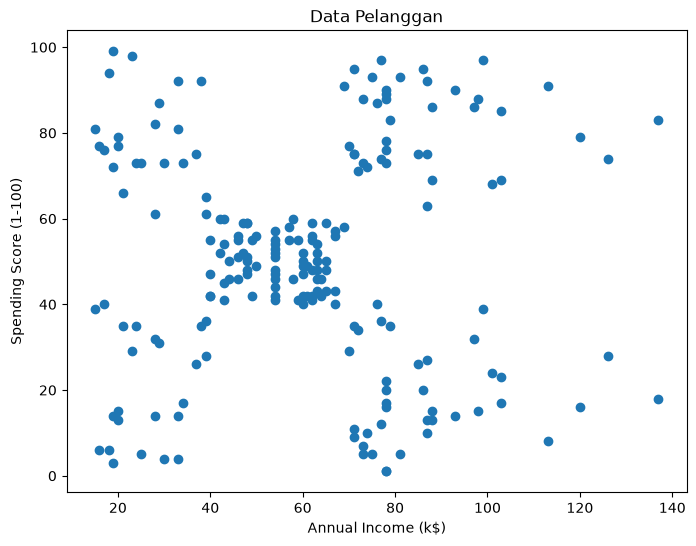

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Data Pelanggan')
plt.show()

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have

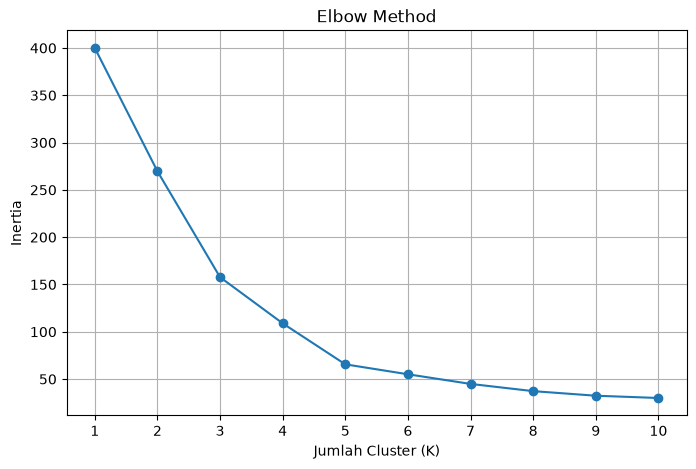

In [20]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K)
plt.grid(True)

plt.show()

c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have

K = 2, Silhouette Score = 0.321
K = 3, Silhouette Score = 0.467
K = 4, Silhouette Score = 0.494
K = 5, Silhouette Score = 0.555
K = 6, Silhouette Score = 0.540
K = 7, Silhouette Score = 0.528
K = 8, Silhouette Score = 0.455
K = 9, Silhouette Score = 0.457
K = 10, Silhouette Score = 0.443


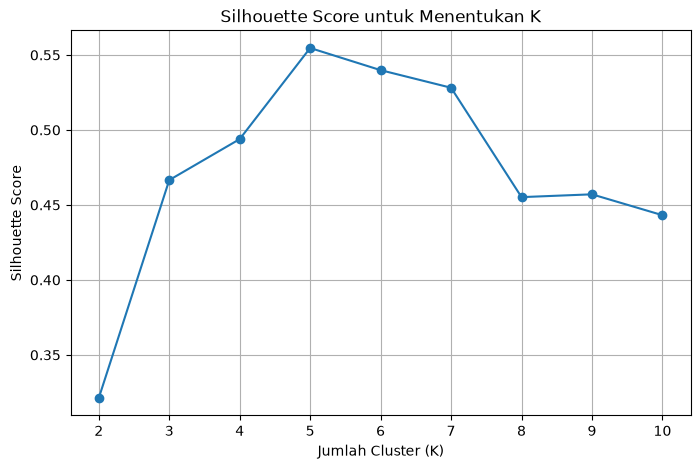

In [21]:
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(K, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")
    
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan K')
plt.xticks(K)
plt.grid(True)

plt.show()

c:\Users\qulbiazzumi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


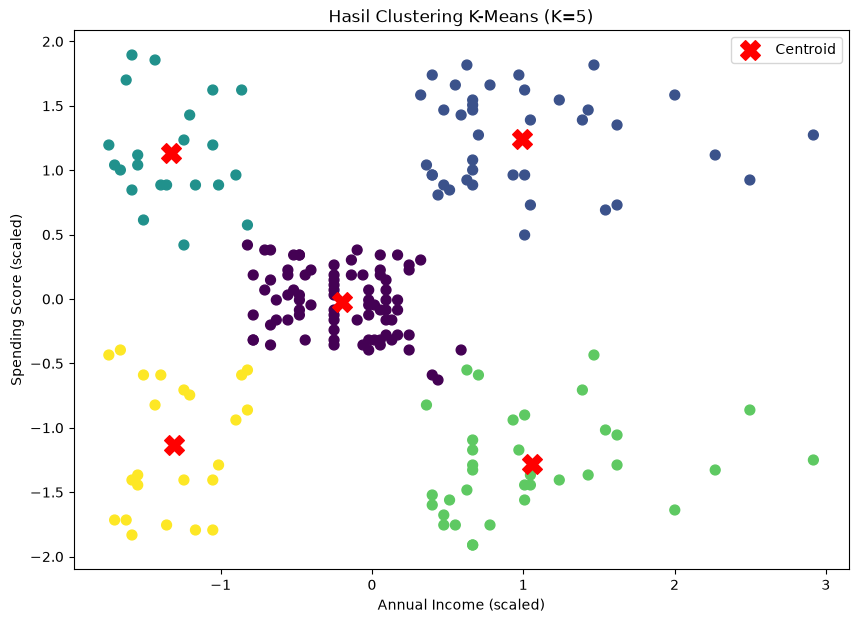

In [23]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

# Centroid
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Hasil Clustering K-Means (K=5)')
plt.legend()

plt.show()

In [25]:
print(df['Cluster'].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [26]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


Pada tugas K-Means digunakan dataset Mall_Customers.csv. Fitur yang digunakan untuk melakukan clustering adalah Annual Income (k$) dan Spending Score (1-100) karena kedua fitur tersebut dapat menggambarkan kondisi ekonomi dan pola pengeluaran pelanggan. Data kemudian dinormalisasi menggunakan StandardScaler.

Penentuan jumlah cluster dilakukan menggunakan Elbow Method dan Silhouette Score. Berdasarkan hasil evaluasi, model kemudian dibuat menggunakan jumlah cluster yang dipilih. Hasil clustering divisualisasikan menggunakan scatter plot dan centroid K-Means. Setiap cluster selanjutnya dianalisis berdasarkan rata-rata usia, pendapatan tahunan, dan spending score untuk mengetahui karakteristik pelanggan pada masing-masing cluster.

2. Tugas DBSCAN


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

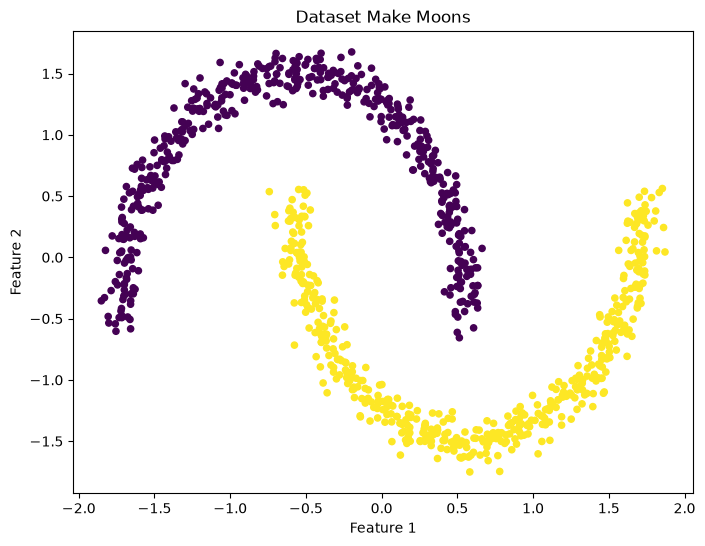

In [29]:
X, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# Normalisasi
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_true,
    cmap='viridis',
    s=20
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Make Moons')
plt.show()

In [30]:
db = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = db.fit_predict(X)

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 2
Estimated number of noise points: 0


In [31]:
print(
    f"Homogeneity: "
    f"{metrics.homogeneity_score(labels_true, labels):.3f}"
)

print(
    f"Completeness: "
    f"{metrics.completeness_score(labels_true, labels):.3f}"
)

print(
    f"V-measure: "
    f"{metrics.v_measure_score(labels_true, labels):.3f}"
)

print(
    f"Adjusted Rand Index: "
    f"{metrics.adjusted_rand_score(labels_true, labels):.3f}"
)

print(
    f"Adjusted Mutual Information: "
    f"{metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)

print(
    f"Silhouette Coefficient: "
    f"{metrics.silhouette_score(X, labels):.3f}"
)

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.391


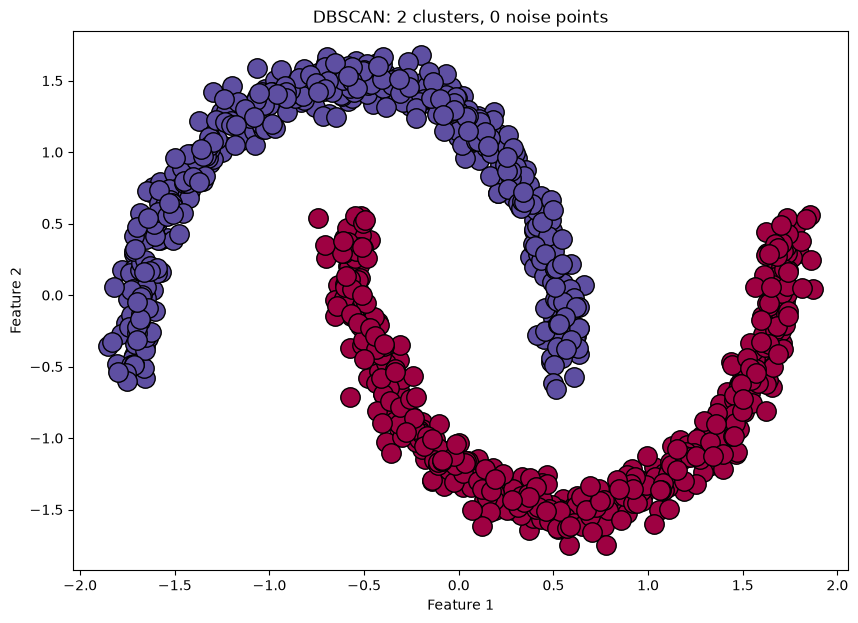

In [32]:
unique_labels = set(labels)

# Menentukan core samples
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Warna untuk setiap cluster
colors = [
    plt.cm.Spectral(each)
    for each in np.linspace(0, 1, len(unique_labels))
]

plt.figure(figsize=(10, 7))

for k, col in zip(unique_labels, colors):

    if k == -1:
        # Noise berwarna hitam
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Core samples = titik besar
    xy = X[class_member_mask & core_samples_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=14
    )

    # Non-core samples = titik kecil
    xy = X[class_member_mask & ~core_samples_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=6
    )

plt.title(
    f'DBSCAN: {n_clusters_} clusters, '
    f'{n_noise_} noise points'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

In [34]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        n_noise = list(labels).count(-1)

        # Evaluasi
        homogeneity = metrics.homogeneity_score(
            labels_true,
            labels
        )

        completeness = metrics.completeness_score(
            labels_true,
            labels
        )

        v_measure = metrics.v_measure_score(
            labels_true,
            labels
        )

        ari = metrics.adjusted_rand_score(
            labels_true,
            labels
        )

        ami = metrics.adjusted_mutual_info_score(
            labels_true,
            labels
        )

        # Silhouette hanya dihitung jika terdapat
        # minimal 2 label berbeda
        if len(set(labels)) >= 2:
            silhouette = metrics.silhouette_score(
                X,
                labels
            )
        else:
            silhouette = np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise': n_noise,
            'homogeneity': homogeneity,
            'completeness': completeness,
            'v_measure': v_measure,
            'ARI': ari,
            'AMI': ami,
            'silhouette': silhouette
        })
        
results_df = pd.DataFrame(results)

results_df.round(3)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,69,186,0.816,0.153,0.257,0.030,0.244,0.113
1,0.05,10,3,970,0.031,0.127,0.049,0.002,0.046,-0.294
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,2,14,0.986,0.903,0.943,0.972,0.943,0.252
4,0.10,10,7,57,0.943,0.410,0.571,0.523,0.570,0.162
5,0.10,20,6,850,0.154,0.155,0.155,0.017,0.151,-0.360
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.391
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.391
9,0.50,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391


In [35]:
results_df.round(3)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,69,186,0.816,0.153,0.257,0.030,0.244,0.113
1,0.05,10,3,970,0.031,0.127,0.049,0.002,0.046,-0.294
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,2,14,0.986,0.903,0.943,0.972,0.943,0.252
4,0.10,10,7,57,0.943,0.410,0.571,0.523,0.570,0.162
5,0.10,20,6,850,0.154,0.155,0.155,0.017,0.151,-0.360
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.391
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.391
9,0.50,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391


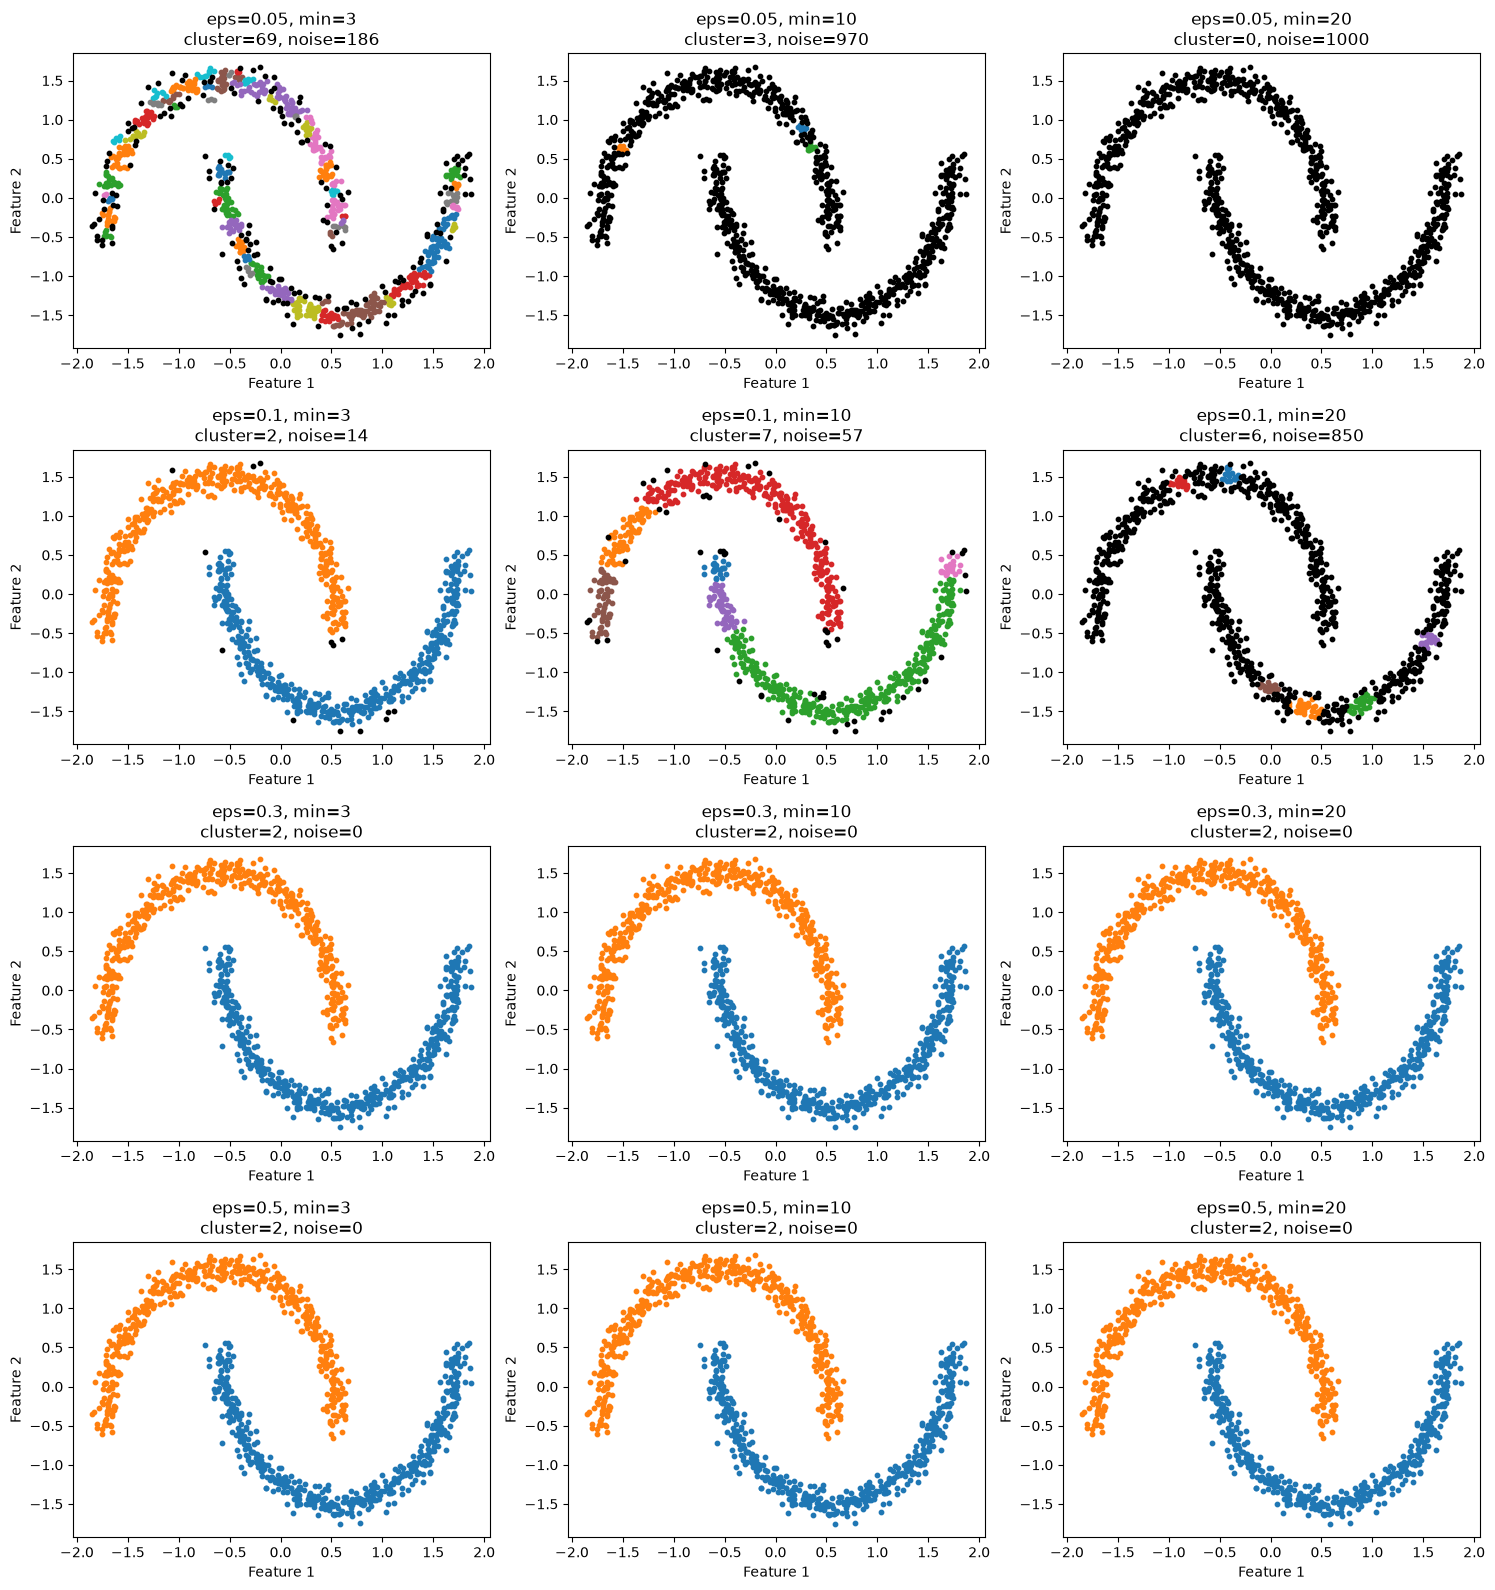

In [36]:
fig, axes = plt.subplots(
    4, 3,
    figsize=(15, 16)
)

for ax, eps in zip(axes.flatten(), [
    (0.05, 3), (0.05, 10), (0.05, 20),
    (0.1, 3), (0.1, 10), (0.1, 20),
    (0.3, 3), (0.3, 10), (0.3, 20),
    (0.5, 3), (0.5, 10), (0.5, 20)
]):

    eps_value, min_samples = eps

    db = DBSCAN(
        eps=eps_value,
        min_samples=min_samples
    )

    labels = db.fit_predict(X)

    unique_labels = set(labels)

    for k in unique_labels:

        class_mask = labels == k

        if k == -1:
            ax.scatter(
                X[class_mask, 0],
                X[class_mask, 1],
                c='black',
                s=10
            )
        else:
            ax.scatter(
                X[class_mask, 0],
                X[class_mask, 1],
                s=10
            )

    n_clusters = len(unique_labels) - (
        1 if -1 in unique_labels else 0
    )

    n_noise = np.sum(labels == -1)

    ax.set_title(
        f'eps={eps_value}, min={min_samples}\n'
        f'cluster={n_clusters}, noise={n_noise}'
    )

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

Pada tugas DBSCAN digunakan dataset make_moons dengan 1000 sampel dan noise sebesar 0.05. Data kemudian dinormalisasi menggunakan StandardScaler. Model awal menggunakan eps=0.2 dan min_samples=5, kemudian dilakukan evaluasi menggunakan Homogeneity, Completeness, V-measure, Adjusted Rand Index, Adjusted Mutual Information, dan Silhouette Coefficient.

Eksperimen selanjutnya dilakukan dengan mengubah nilai eps menjadi 0.05, 0.1, 0.3, dan 0.5 serta min_samples menjadi 3, 10, dan 20. Perubahan parameter tersebut memengaruhi jumlah cluster dan jumlah noise yang dihasilkan. Nilai eps yang terlalu kecil menyebabkan banyak titik dianggap noise atau membentuk cluster kecil, sedangkan peningkatan eps membuat lebih banyak titik terhubung. Parameter min_samples yang lebih besar membuat persyaratan sebuah titik untuk menjadi core point semakin ketat sehingga dapat meningkatkan jumlah noise.

Hasil evaluasi menunjukkan bahwa pemilihan parameter DBSCAN sangat berpengaruh terhadap hasil clustering. Oleh karena itu, eps dan min_samples perlu disesuaikan dengan distribusi dan kepadatan data.